# Ejercicio 5: Incorporación de datos de 2024

En este ejercicio tocaba agregar los datos de 2024. La idea era ver si el sistema que hicimos para 2026 aguantaba datos de otro año sin tener que cambiar las consultas.

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

import duckdb
import pandas as pd
import consultas

print(f"DuckDB version: {duckdb.__version__}")
print(f"Directorio actual: {Path.cwd()}")

DuckDB version: 1.5.5
Directorio actual: /workspace/notebooks


## 5.1 Modificación del sistema de descarga

Tuvimos que cambiar el script `download_data.py` porque antes solo bajaba 2026. Le agregamos el argumento `--anios` para que pueda bajar varios años. La buena noticia es que si ya tenías los archivos, no los vuelve a bajar.

In [2]:
!python scripts/download_data.py --anios 2024

python: can't open file '/workspace/notebooks/scripts/download_data.py': [Errno 2] No such file or directory


## 5.2-5.3 Verificación de archivos existentes

Corrimos el script con `--verificar` para ver que todo estuviera bien. Los 24 archivos de 2024 ya estaban en disco, así que no se volvió a bajar nada. Eso es lo que queríamos: que no repita descargas.

In [3]:
!python scripts/download_data.py --verificar --anios 2024

python: can't open file '/workspace/notebooks/scripts/download_data.py': [Errno 2] No such file or directory


## 5.4-5.5 Verificación de incorporación correcta

Aquí lo importante era ver si DuckDB podía ver 2024 y 2026 al mismo tiempo. Resulta que sí, sin hacer nada especial, porque las vistas usan glob patterns que capturan cualquier año.

In [4]:
con = consultas.conectar()

print("=== Validación de años ===")
validacion = consultas.correr(con, "04_validar_anios.sql")
display(validacion)

=== Validación de años ===


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,2024-01,2024-12,41169720.0
1,yellow,2025,12,2025-01,2025-12,48722602.0
2,yellow,2026,8,2026-01,2026-08,29703355.0
3,green,2024,12,2024-01,2024-12,660218.0
4,green,2025,12,2025-01,2025-12,591375.0
5,green,2026,8,2026-01,2026-08,337114.0


## 5.6 Consulta conjunta de 2024 y 2026

DuckDB consulta ambos años sin problemas. No tuvimos que tocar ninguna consulta porque las vistas usan patrones como `data/raw/*/*/*.parquet` que agarran cualquier año automáticamente.

In [5]:
print("\n=== Comparación mensual (enero-agosto) ===")
comparacion = consultas.correr(con, "04_comparacion_mensual.sql")
display(comparacion.head(6))


=== Comparación mensual (enero-agosto) ===


,tipo,anio,mes,viajes_por_dia
0,yellow,2024,1,95633.451613
1,yellow,2026,1,120158.096774
2,yellow,2024,2,103708.068966
3,yellow,2026,2,121423.785714
4,yellow,2024,3,115568.161290
5,yellow,2026,3,127498.161290


In [6]:
print("\n=== Índice 2024 = 100 ===")
indice = consultas.correr(con, "04_indice_mensual.sql")
display(indice.head(4))


=== Índice 2024 = 100 ===


,tipo,anio,mes,viajes_por_dia,indice_2024_100
0,yellow,2024,1,95633.451613,100.000000
1,yellow,2026,1,120158.096774,125.644421
2,yellow,2024,2,103708.068966,100.000000
3,yellow,2026,2,121423.785714,117.082294


## 5.7 ¿Necesitan modificarse las consultas?

**No.** Las consultas que hicimos antes siguen funcionando. Esto es porque:

1. Las vistas en `sql/00_vistas.sql` leen `data/raw/*/*/*.parquet`, así que cualquier año nuevo entra solo
2. La vista `viajes_validos` saca el año del nombre del archivo, así que funciona con 2024, 2026 o lo que sea
3. Las consultas agrupan por `anio` y `mes`, así que distinguen entre años sin problema

**Lo único:** Las consultas `03_viajes_por_mes.sql` y `03_pago_por_mes.sql` agrupan solo por `mes` sin `anio`, así que ahora mezclan 2024 con 2026. Para comparar años tuvimos que hacer las consultas `04_comparacion_mensual.sql` e `04_indice_mensual.sql` que sí distinguen.

## 5.8-5.9 Características del diseño que permiten incorporar nuevos datos

Lo chido es que el sistema aguanta 2024, 2025 o cualquier año sin tocar el análisis. Esto funciona porque:

1. **Vistas sobre glob patterns:** Las vistas leen `data/raw/<tipo>/*/*.parquet`, así que un año nuevo que caiga en `data/raw/<tipo>/<anio>/` entra automáticamente sin tocar ninguna consulta.

2. **Separación de datos y análisis:** Los datos viven en `data/raw/` y las consultas en `sql/`. Agregar datos no requiere cambiar código.

3. **Extracción de año desde el archivo:** La vista `viajes_validos` saca el año del nombre del archivo con `split_part(filename, '/', -2)`, así que funciona con cualquier año.

4. **Script de descarga parametrizable:** El script acepta `--anios 2024 2025 2026` y baja solo lo que falta, sin repetir archivos.

**En resumen:** El diseño es incremental y reproducible. Solo corres el script con los años nuevos y las consultas existentes funcionan automáticamente.

## Comparación visual 2024 vs 2026

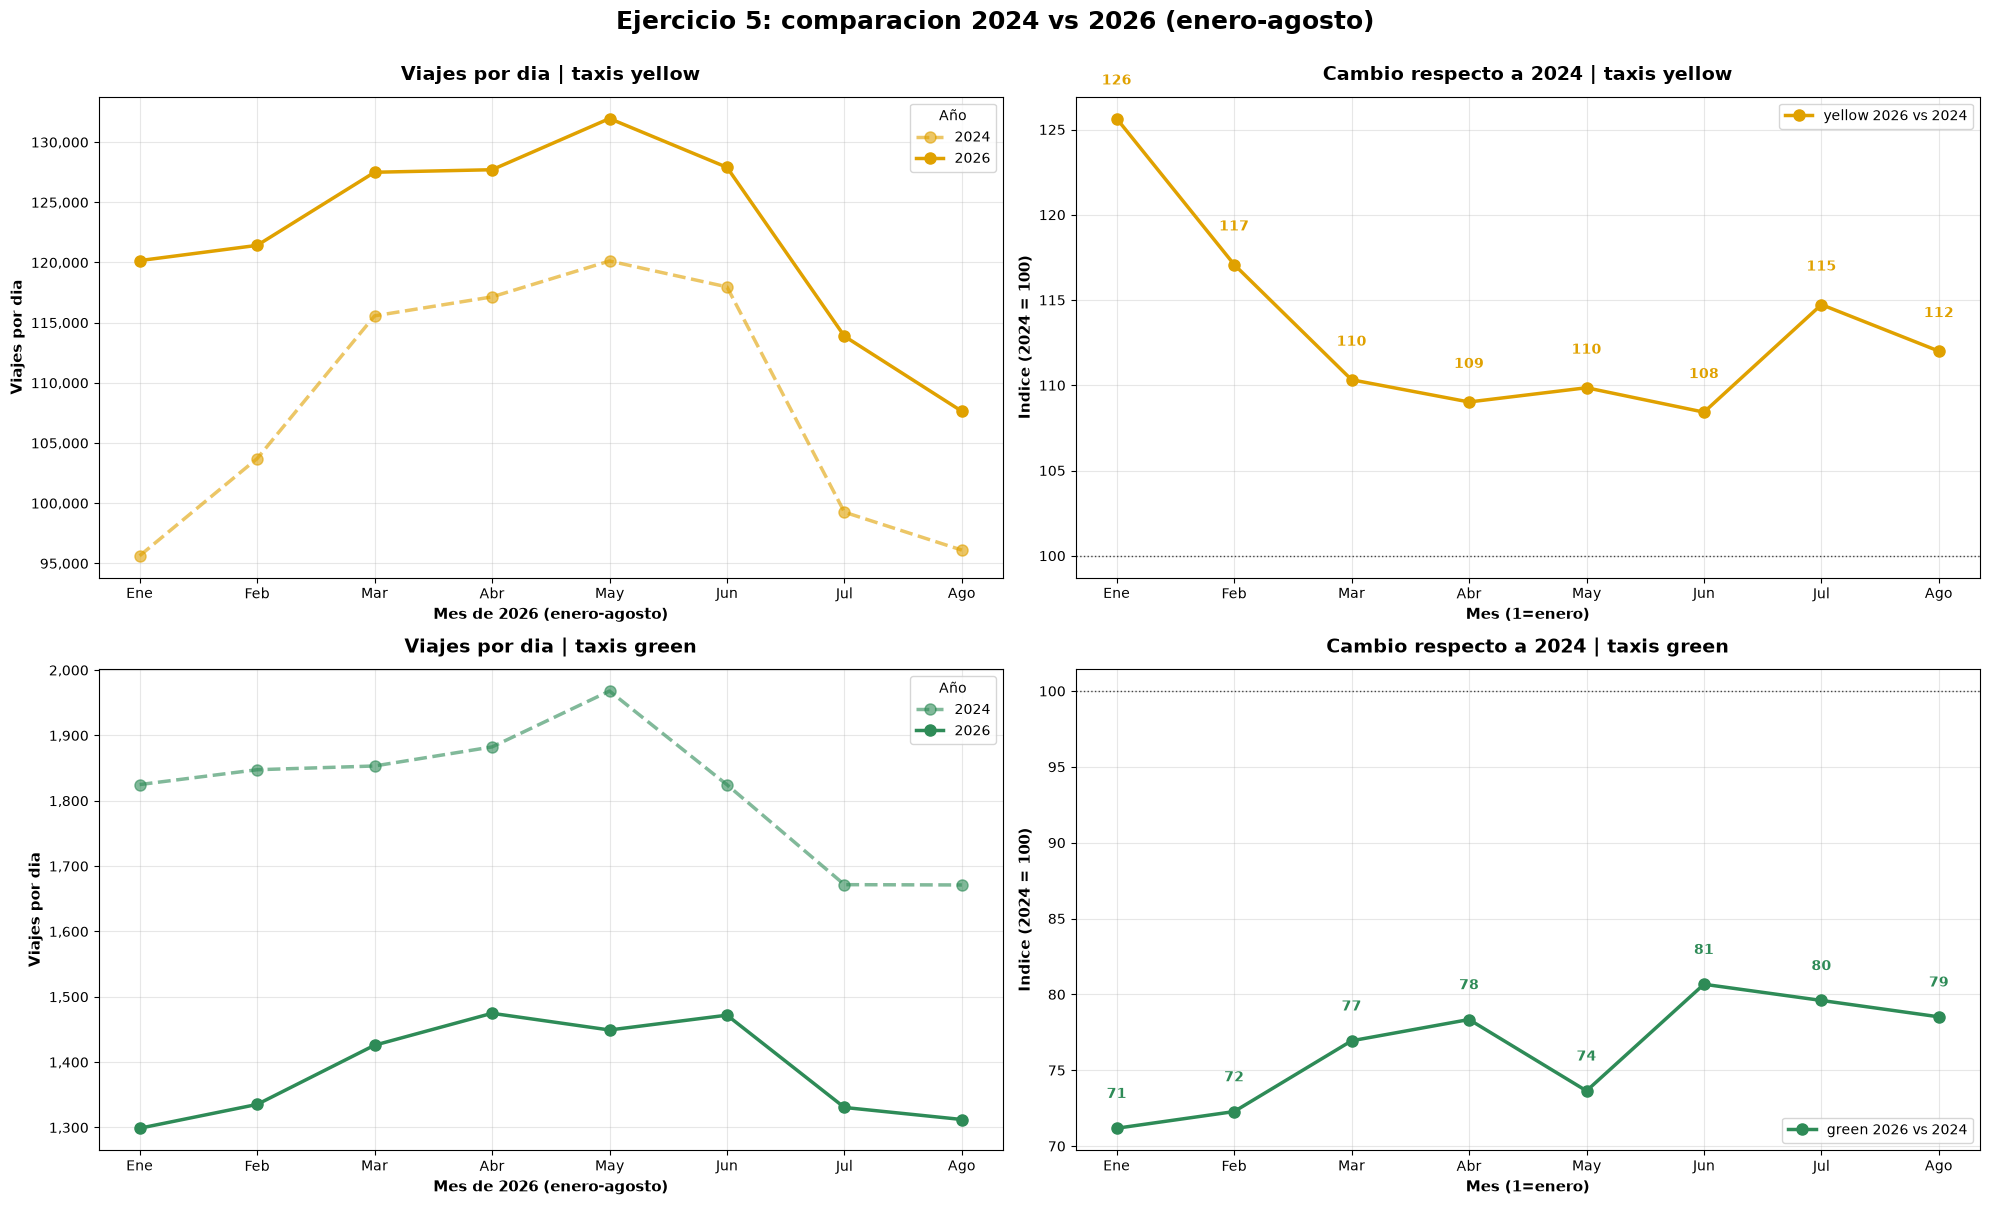


=== Cambio porcentual 2026 vs 2024 (mes y tipo) ===


tipo,green,yellow
Ene,-28.8,25.6
Feb,-27.7,17.1
Mar,-23.1,10.3
Abr,-21.7,9.0
May,-26.4,9.9
Jun,-19.3,8.4
Jul,-20.4,14.7
Ago,-21.5,12.0



=== Cambio promedio 2026 vs 2024 (enero-agosto) ===
  yellow  : +13.4% en promedio (min +8.4%, max +25.6%)
  green   : -23.6% en promedio (min -28.8%, max -19.3%)


In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul",8:"Ago"}

Path("data/processed/figuras").mkdir(parents=True, exist_ok=True)

def graficar_comparacion_anual(comparacion, indice):
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    for i, tipo in enumerate(["yellow", "green"]):
        ax_izq = axes[i, 0]
        datos = comparacion[comparacion["tipo"] == tipo]
        for anio, estilo, alpha in [("2024", "--", 0.6), ("2026", "-", 1.0)]:
            d = datos[datos["anio"].astype(str) == anio].sort_values("mes")
            ax_izq.plot(d["mes"], d["viajes_por_dia"], estilo,
                        color=COLOR_TAXI[tipo], linewidth=2.5, marker="o",
                        markersize=8, alpha=alpha, label=anio)
        ax_izq.set_xticks(range(1, 9), [MESES_ES[m] for m in range(1, 9)])
        ax_izq.set_title(f"Viajes por dia | taxis {tipo}",
                         fontsize=14, fontweight="bold", pad=12)
        ax_izq.set_xlabel("Mes de 2026 (enero-agosto)", fontsize=11, fontweight="bold")
        ax_izq.set_ylabel("Viajes por dia", fontsize=11, fontweight="bold")
        ax_izq.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax_izq.grid(alpha=0.3)
        ax_izq.legend(title="Año", fontsize=10)

        ax_der = axes[i, 1]
        d_idx = indice[(indice["tipo"] == tipo) & (indice["anio"].astype(str) == "2026")].sort_values("mes")
        ax_der.plot(d_idx["mes"], d_idx["indice_2024_100"], "-",
                    color=COLOR_TAXI[tipo], linewidth=2.5, marker="o",
                    markersize=8, label=f"{tipo} 2026 vs 2024")
        ax_der.axhline(100, color="#444444", linestyle=":", linewidth=1)
        for _, r in d_idx.iterrows():
            ax_der.text(r["mes"], r["indice_2024_100"] + 2,
                        f"{r['indice_2024_100']:.0f}",
                        ha="center", fontsize=10, fontweight="bold",
                        color=COLOR_TAXI[tipo])
        ax_der.set_xticks(range(1, 9), [MESES_ES[m] for m in range(1, 9)])
        ax_der.set_title(f"Cambio respecto a 2024 | taxis {tipo}",
                         fontsize=14, fontweight="bold", pad=12)
        ax_der.set_xlabel("Mes (1=enero)", fontsize=11, fontweight="bold")
        ax_der.set_ylabel("Indice (2024 = 100)", fontsize=11, fontweight="bold")
        ax_der.grid(alpha=0.3)
        ax_der.legend(fontsize=10)

    fig.suptitle("Ejercicio 5: comparacion 2024 vs 2026 (enero-agosto)",
                 fontsize=18, fontweight="bold", y=1.00)
    fig.tight_layout()
    fig.savefig("data/processed/figuras/04_comparacion_2024_2026.png",
                bbox_inches="tight", dpi=110)
    return fig, axes

fig, _ = graficar_comparacion_anual(comparacion, indice)
plt.show()

print("\n=== Cambio porcentual 2026 vs 2024 (mes y tipo) ===")
pivote = indice.pivot_table(
    index=["tipo", "mes"], columns="anio", values="viajes_por_dia"
).reset_index()
pivote.columns.name = None
pivote["cambio_pct"] = 100 * (pivote["2026"] / pivote["2024"] - 1)
tabla_cambio = pivote.pivot(index="mes", columns="tipo", values="cambio_pct").round(1)
tabla_cambio.index = [MESES_ES[m] for m in tabla_cambio.index]
display(tabla_cambio)

print("\n=== Cambio promedio 2026 vs 2024 (enero-agosto) ===")
for tipo in ["yellow", "green"]:
    d = pivote[pivote["tipo"] == tipo]
    print(f"  {tipo:8s}: {d['cambio_pct'].mean():+.1f}% en promedio "
          f"(min {d['cambio_pct'].min():+.1f}%, max {d['cambio_pct'].max():+.1f}%)")